This script performs:

1. pIC50 distribution for all AD targets.
2. Normality check of pIC50 - Shapiro-Wilk and D’Agostino tests


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Install RDKit
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 56.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, normaltest
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import os

In [ ]:
# === Load the descriptor dataset ===

input_path = "/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/data/descriptors"
target_files = {
    "bace1": "bace1_features.csv",
    "buche": "buche_features.csv",
    "ache": "ache_features.csv",
    #"gsk-3beta": "gsk-3beta_features.csv",
    "mao-b": "mao-b_features.csv",
    #"esr1": "esr1_features.csv",
    "5-HT6": "5-HT6_features.csv"
}

# **Plot pIC50 histograms**

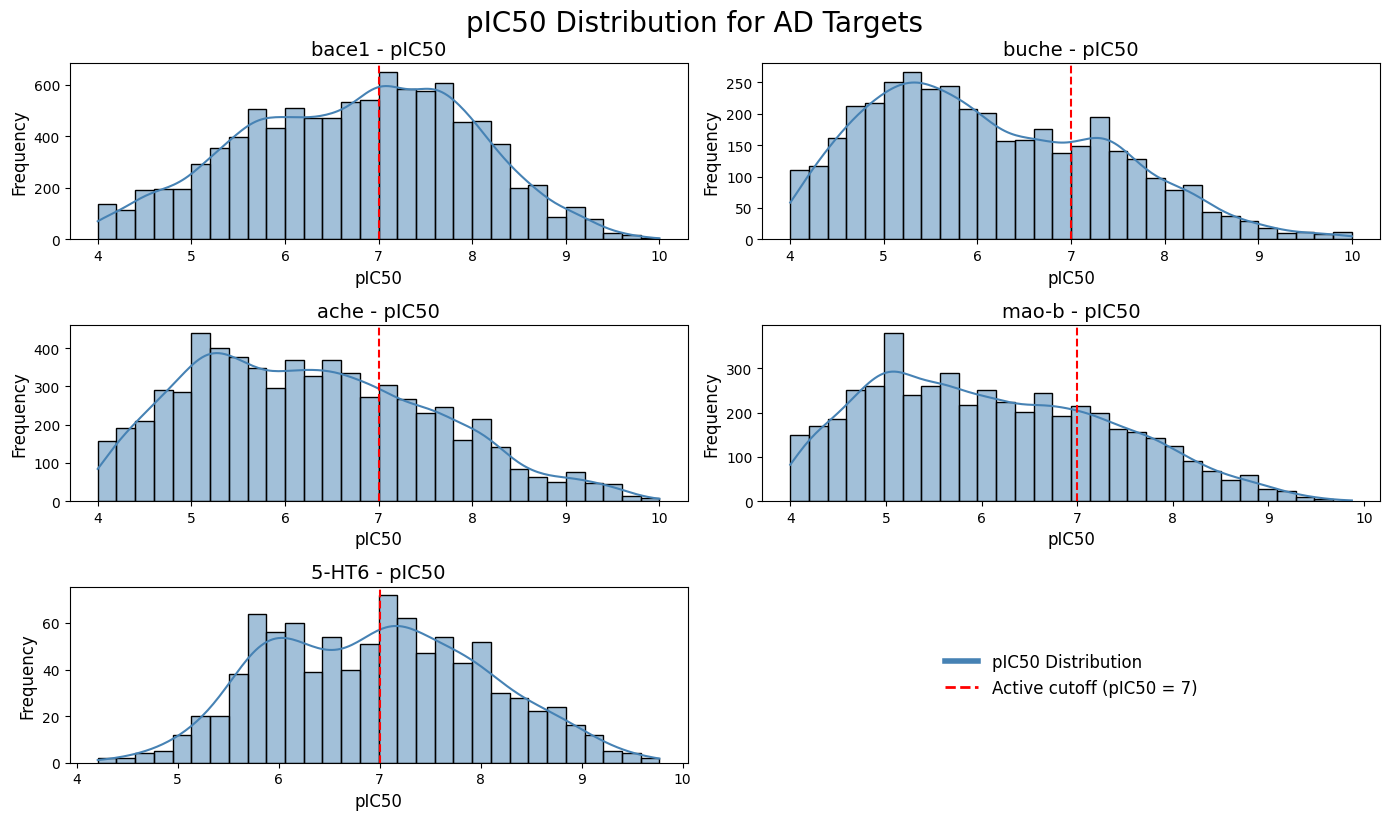

In [ ]:
# Set up the plot grid
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
axes = axes.flatten()


# Plot histograms with KDE
for idx, (target, filename) in enumerate(target_files.items()):
    df = pd.read_csv(os.path.join(input_path, filename))
    ax = axes[idx]

    sns.histplot(df['pIC50'], bins=30, kde=True, ax=ax, color='steelblue')
    ax.axvline(7, color='red', linestyle='--')
    ax.set_title(f'{target} - pIC50', fontsize=14)
    ax.set_xlabel('pIC50', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

# Use the last empty subplot for the global legend
if len(target_files) < 8:
    legend_ax = axes[-1]
    legend_ax.axis('off')  # turn off axis

    # Create dummy plots to generate a single legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='steelblue', lw=4, label='pIC50 Distribution'),
        Line2D([0], [0], color='red', lw=2, linestyle='--', label='Active cutoff (pIC50 = 7)')
    ]
    legend_ax.legend(handles=legend_elements, loc='center', fontsize=12, frameon=False)

plt.tight_layout()
plt.suptitle("pIC50 Distribution for AD Targets", fontsize=20, y=1.02)
plt.savefig("/content/drive/MyDrive/Colab Notebooks/ESOFT-MSC/thesis-project/Figures/pIC50_distribution_AD_targets_2.png", bbox_inches='tight', dpi=300)
plt.show()


# **Test for Normality**

In [ ]:
print("Shapiro-Wilk Normality Test on pIC50")
print("-" * 50)

for target, filename in target_files.items():
    filepath = os.path.join(input_path, filename)
    df = pd.read_csv(filepath)

    stat, p_value = shapiro(df['pIC50'])

    result = "NOT normal (p < 0.05)" if p_value < 0.05 else "Normal (p ≥ 0.05)"
    print(f"{target}: W = {stat:.4f}, p = {p_value:.4f} → {result}")

Shapiro-Wilk Normality Test on pIC50
--------------------------------------------------


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 9799.
  res = hypotest_fun_out(*samples, **kwds)


bace1: W = 0.9898, p = 0.0000 → NOT normal (p < 0.05)
buche: W = 0.9678, p = 0.0000 → NOT normal (p < 0.05)


/usr/local/lib/python3.11/dist-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 6629.
  res = hypotest_fun_out(*samples, **kwds)


ache: W = 0.9762, p = 0.0000 → NOT normal (p < 0.05)
gsk-3beta: W = 0.9873, p = 0.0000 → NOT normal (p < 0.05)
mao-b: W = 0.9707, p = 0.0000 → NOT normal (p < 0.05)
esr1: W = 0.9750, p = 0.0000 → NOT normal (p < 0.05)
5-HT6: W = 0.9897, p = 0.0000 → NOT normal (p < 0.05)


Shapiro-Wilk statistic (W) ranges from 0 to 1:

Values closer to 1 → data more normally distributed.

Values < 1 → deviation from normality.

p-values are all less than 0.05 → This means that for all datasets, the null hypothesis of normality is rejected, i.e., pIC₅₀ is not normally distributed for any of the targets.

Since pIC50 values are not normally distributed (based on the Shapiro-Wilk test:

- Choose models that are robust to non-normal data (e.g., tree-based models, XGBoost). Some models (e.g., linear regression, LDA) assume that features or residuals are normally distributed for optimal performance.

- Be cautious if using parametric statistical tests. Indicate that transformation (e.g., log-transform) or robust metrics (like median, IQR) are more appropriate than mean/std.